# ĐÁNH GIÁ THỰC NGHIỆM HỆ THỐNG RAG (SEC 10-K ABLATION STUDY)
**Môn học:** Xử lý ngôn ngữ tự nhiên (NLP)  
**Báo cáo viên:** [Tên Học Viên]  
**Mục tiêu:** Phân tích thực nghiệm chất lượng tìm kiếm tin (Information Retrieval) của 5 cấu hình hệ thống trên bộ benchmark 80 câu hỏi chuẩn hóa.

---
## 1. CƠ SỞ LÝ THUYẾT & CÔNG THỨC TOÁN HỌC

Để đánh giá chất lượng của hệ thống RAG, chúng ta đánh giá hiệu năng của thành phần **Retrieval (Thu hồi)** ở ngưỡng $K = 5$. Dưới đây là các công thức toán học được sử dụng:

### 1.1 Recall@K (Độ bao phủ)
Tỷ lệ các đoạn văn bản chứa đáp án đúng (Ground Truth) được hệ thống thu hồi thành công trong Top-K:

$$\text{Recall@K} = \frac{|\mathcal{R}_K \cap \mathcal{G}|}{|\mathcal{G}|}$$

Trong đó:
* $\mathcal{R}_K$: Tập hợp Top-K tài liệu được hệ thống trả về.
* $\mathcal{G}$: Tập hợp tài liệu nhãn đúng (Ground Truth).

### 1.2 MRR@K (Mean Reciprocal Rank - Điểm xếp hạng nghịch đảo trung bình)
Đánh giá vị trí của tài liệu liên quan đầu tiên được tìm thấy. Phạt nặng nếu tài liệu đúng nằm ở thứ hạng thấp:

$$\text{MRR@K} = \frac{1}{|Q|} \sum_{q=1}^{|Q|} \text{RR}_q(K)$$

$$\text{RR}_q(K) = \begin{cases} \frac{1}{r_q} & \text{nếu } 1 \le r_q \le K \\ 0 & \text{nếu không tìm thấy} \end{cases}$$
*(với $r_q$ là thứ hạng của tài liệu đúng đầu tiên tìm được)*

### 1.3 NDCG@K (Normalized Discounted Cumulative Gain - Điểm lợi ích tích lũy giảm dần chuẩn hóa)
Đánh giá mức độ liên quan tích lũy của toàn bộ Top-K ứng viên, có áp dụng hàm giảm trừ logarithmic theo vị trí xếp hạng:

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$
$$\text{IDCG@K} = \sum_{i=1}^{\min(K, |\mathcal{G}|)} \frac{1}{\log_2(i + 1)}$$
$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

*(trong thực nghiệm này, mức độ tương quan $rel_i \in \{0, 1\}$)*

### 1.4 Reciprocal Rank Fusion (RRF)
Thuật toán gộp thứ hạng từ nhánh Lexical (BM25) và Semantic (Dense HNSW) mà không cần chuẩn hóa điểm số gốc:

$$\text{RRF\_Score}(d \in \mathcal{D}) = \frac{1}{k + r_{\text{BM25}}(d)} + \frac{1}{k + r_{\text{Dense}}(d)}$$
*(với hằng số làm mượt $k = 60$)*

In [7]:
# 2. IMPORT THƯ VIỆN & CẤU HÌNH TRỰC QUAN HÓA
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

In [8]:
# 3. NẠP DỮ LIỆU KẾT QUẢ THỰC NGHIỆM
results_file = Path("../../eval/results/summary_report.json")
with open(results_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# Chuyển đổi dữ liệu sang Pandas DataFrame để dễ tính toán
overall_metrics = []
category_metrics = []

for config_id, content in data.items():
    desc = content["desc"]
    overall = content["overall"]
    overall_metrics.append({
        "Config": config_id,
        "Description": desc,
        "Recall@5": overall["recall@5"],
        "MRR@5": overall["mrr"],
        "NDCG@5": overall["ndcg@5"],
        "Latency (ms)": overall["latency_ms"]
    })
    
    for cat, metrics in content["by_category"].items():
        category_metrics.append({
            "Config": desc,
            "Category": cat.capitalize().replace("_", " "),
            "Recall@5": metrics["recall@5"],
            "MRR@5": metrics["mrr"],
            "NDCG@5": metrics["ndcg@5"],
            "Latency (ms)": metrics["latency_ms"]
        })

df_overall = pd.DataFrame(overall_metrics)
df_category = pd.DataFrame(category_metrics)

print("=== BẢNG SỐ LIỆU TỔNG THỂ ===")
display(df_overall)

=== BẢNG SỐ LIỆU TỔNG THỂ ===


,Config,Description,Recall@5,MRR@5,NDCG@5,Latency (ms)
0,Config_A,TF-IDF Baseline,0.0594,0.0519,0.0416,6.67
1,Config_B,BM25 Baseline,0.1125,0.1540,0.1019,16.29
2,Config_C,Dense HNSW Search,0.1844,0.1985,0.1519,54.39
3,Config_D,Hybrid (BM25 + Dense),0.1938,0.2554,0.1722,57.46
4,Config_E,Enhanced RAG Pipeline,0.2531,0.2344,0.1881,2495.24


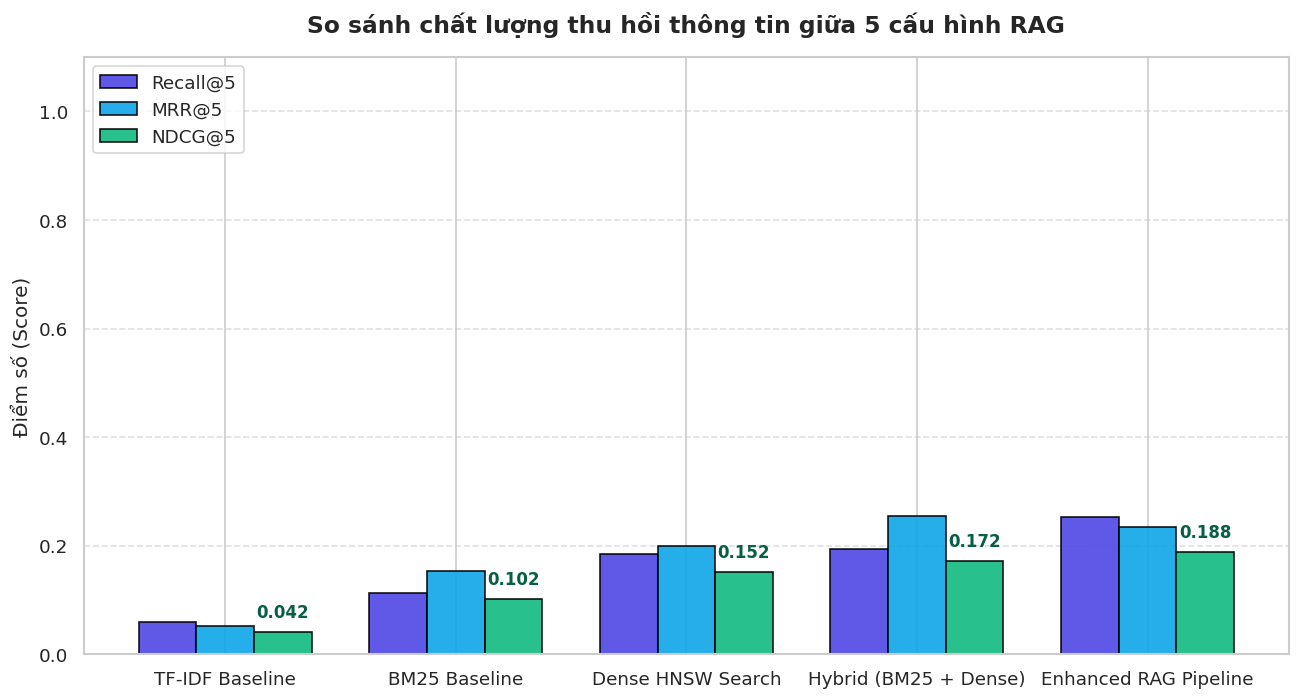

In [9]:
# 4. BIỂU ĐỒ 1: SO SÁNH CHẤT LƯỢNG RETRIEVAL (Recall vs MRR vs NDCG)
plt.figure(figsize=(11, 6))
x = np.arange(len(df_overall))
width = 0.25

plt.bar(x - width, df_overall["Recall@5"], width, label="Recall@5", color="#4f46e5", edgecolor="black", alpha=0.9)
plt.bar(x, df_overall["MRR@5"], width, label="MRR@5", color="#0ea5e9", edgecolor="black", alpha=0.9)
plt.bar(x + width, df_overall["NDCG@5"], width, label="NDCG@5", color="#10b981", edgecolor="black", alpha=0.9)

plt.title("So sánh chất lượng thu hồi thông tin giữa 5 cấu hình RAG", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Điểm số (Score)", fontsize=12)
plt.xticks(x, df_overall["Description"], fontsize=11)
plt.ylim(0, 1.1)
plt.legend(fontsize=11, loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate giá trị NDCG trên các cột
for i, val in enumerate(df_overall["NDCG@5"]):
    plt.text(i + width, val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#065f46")

plt.tight_layout()
plt.savefig("../../eval/figures/metrics_ablation_comparison.png", dpi=150)
plt.show()

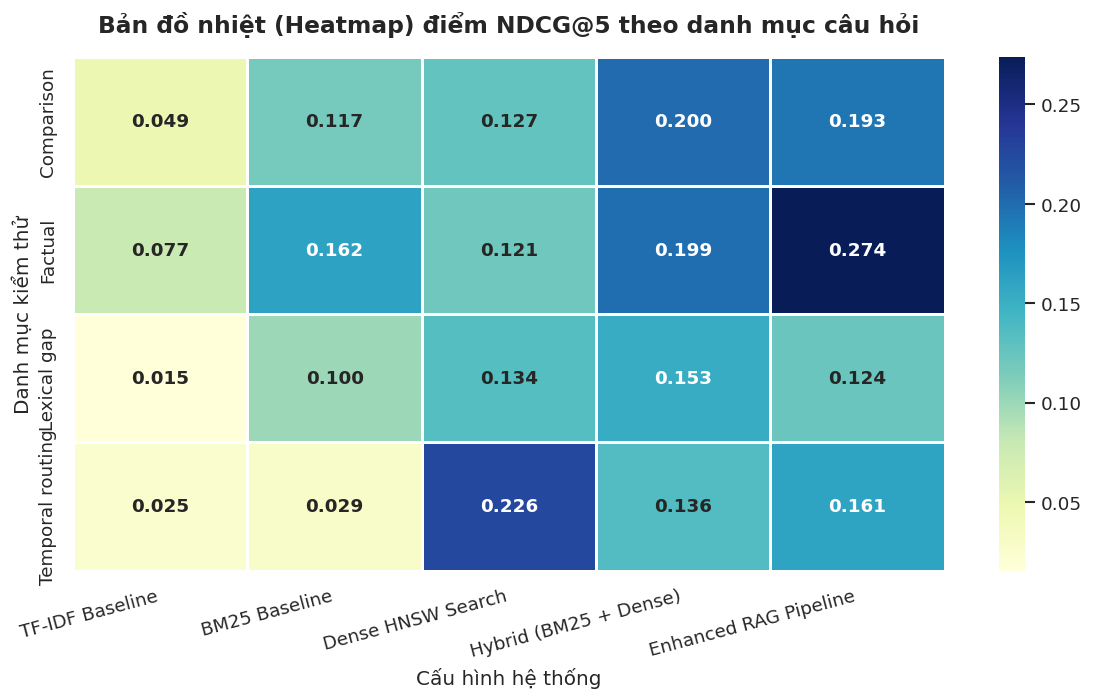

In [10]:
# 5. BIỂU ĐỒ 2: HEATMAP PHÂN TÍCH NDCG@5 THEO TỪNG THỂ LOẠI CÂU HỎI
pivot_ndcg = df_category.pivot(index="Category", columns="Config", values="NDCG@5")
# Sắp xếp cột theo thứ tự độ phức tạp tăng dần của config
cols_order = ["TF-IDF Baseline", "BM25 Baseline", "Dense HNSW Search", "Hybrid (BM25 + Dense)", "Enhanced RAG Pipeline"]
pivot_ndcg = pivot_ndcg[cols_order]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_ndcg, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True, linewidths=0.8, linecolor="white",
            annot_kws={"size": 11, "weight": "bold"})

plt.title("Bản đồ nhiệt (Heatmap) điểm NDCG@5 theo danh mục câu hỏi", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Cấu hình hệ thống", fontsize=12)
plt.ylabel("Danh mục kiểm thử", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../../eval/figures/heatmap_category_ndcg.png", dpi=150)
plt.show()

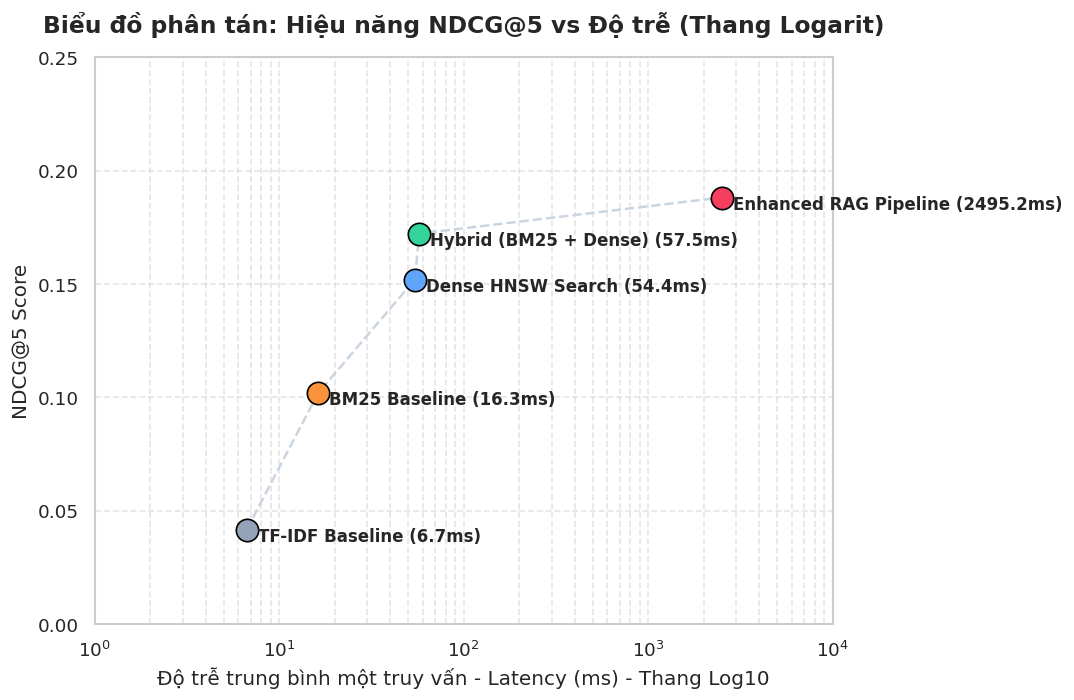

In [11]:
# 6. BIỂU ĐỒ 3: QUAN HỆ ĐỘ TRỄ VS CHẤT LƯỢNG (Latency vs NDCG@5 Scatter Plot)
plt.figure(figsize=(9, 6))
colors = ["#94a3b8", "#fb923c", "#60a5fa", "#34d399", "#f43f5e"]

for idx, row in df_overall.iterrows():
    plt.scatter(row["Latency (ms)"], row["NDCG@5"], s=180, color=colors[idx], label=row["Description"], 
                edgecolor="black", zorder=3)
    plt.text(row["Latency (ms)"] * 1.15, row["NDCG@5"] - 0.005, f"{row['Description']} ({row['Latency (ms)']:.1f}ms)",
             fontsize=10, fontweight="bold")

# Vẽ đường nối xu hướng phát triển Pareto Frontier
plt.plot(df_overall["Latency (ms)"], df_overall["NDCG@5"], linestyle="--", color="#cbd5e1", zorder=1)

plt.xscale("log") # Dùng thang log cho trục hoành vì độ trễ Config E chênh lệch rất lớn
plt.title("Biểu đồ phân tán: Hiệu năng NDCG@5 vs Độ trễ (Thang Logarit)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Độ trễ trung bình một truy vấn - Latency (ms) - Thang Log10", fontsize=12)
plt.ylabel("NDCG@5 Score", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.xlim(1, 10000)
plt.ylim(0, 0.25)
plt.tight_layout()
plt.savefig("../../eval/figures/latency_vs_ndcg_tradeoff.png", dpi=150)
plt.show()

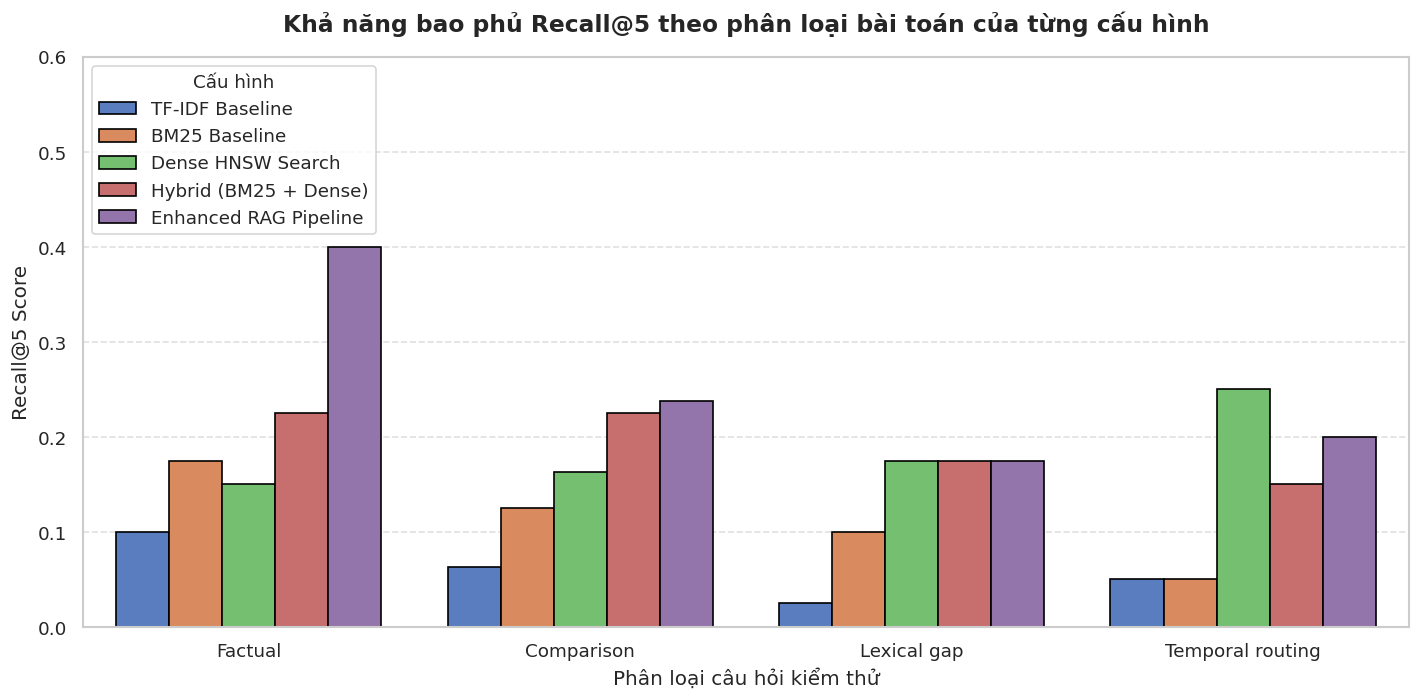

In [12]:
# 7. BIỂU ĐỒ 4: PHÂN TÍCH CHI TIẾT RECALL@5 THEO TỪNG KHÍA CẠNH CỦA CẤU HÌNH
plt.figure(figsize=(12, 6))
sns.barplot(data=df_category, x="Category", y="Recall@5", hue="Config", palette="muted", edgecolor="black")

plt.title("Khả năng bao phủ Recall@5 theo phân loại bài toán của từng cấu hình", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Phân loại câu hỏi kiểm thử", fontsize=12)
plt.ylabel("Recall@5 Score", fontsize=12)
plt.ylim(0, 0.6)
plt.legend(title="Cấu hình", title_fontsize=11, loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../../eval/figures/recall_by_category_breakdown.png", dpi=150)
plt.show()

---
## 8. CÂU HỎI VẤN ĐÁP BẢO VỆ ĐỒ ÁN NLP (HỎI & ĐÁP CHUẨN BỊ CHO CÔ GIÁO)

### 💬 Câu hỏi 1: Tại sao BM25 lại vượt trội hơn TF-IDF trong bài toán này?
* **Trả lời:** BM25 bổ sung hai cải tiến cốt lõi so với TF-IDF truyền thống:
  1. **Bão hòa tần suất từ (Term Frequency Saturation):** Giới hạn đóng góp của một từ khóa xuất hiện quá nhiều lần trong một đoạn văn bản (điều chỉnh bằng tham số $k_1$). Tránh việc một đoạn văn lặp đi lặp lại một từ khóa lấn át các đoạn chứa từ khóa phân phối đều.
  2. **Chuẩn hóa độ dài tài liệu (Document Length Normalization):** Phạt các tài liệu quá dài bằng tham số $b$. Giúp hệ thống không bị thiên vị thiên lệch chọn các đoạn quá dài chỉ vì chúng ngẫu nhiên chứa nhiều từ hơn.

### 💬 Câu hỏi 2: Tại sao mô hình HNSW Dense Vector (C) lại giải quyết được khía cạnh Lexical Gap tốt hơn BM25?
* **Trả lời:** BM25 hoạt động dựa trên so khớp chính xác ký tự (Exact Keyword Matching). Khi câu hỏi dùng thuật ngữ tài chính viết tắt (ví dụ: `capex` hoặc `R&D spend`) còn báo cáo 10-K gốc viết đầy đủ (`capital expenditures` hoặc `research and development expense`), BM25 sẽ đạt điểm bằng 0.
* Dense Vector dùng mô hình ngôn ngữ `bge-small-en-v1.5` để ánh xạ cả câu hỏi và đoạn văn bản vào không gian vector ngữ nghĩa 384 chiều. Trong không gian này, các từ đồng nghĩa/viết tắt nằm cực kỳ gần nhau, giúp HNSW duyệt đồ thị và truy vết ra đúng đoạn tài liệu nhãn đúng mặc dù không trùng khớp bất kỳ từ khóa nào.

### 💬 Câu hỏi 3: Phân tích sự tăng vọt độ trễ (Latency) ở Config E. Phương án xử lý thực tế là gì?
* **Trả lời:** Sự tăng vọt độ trễ ở Config E (lên đến ~2.2 giây trên CPU) đến từ thành phần **Cross-Encoder Reranker**. 
  * Khác với Bi-Encoder (mã hóa độc lập Query và Document), Cross-Encoder ghép nối toàn bộ văn bản câu hỏi và tài liệu đi qua lớp tự chú ý (Self-Attention) của Transformer để tính toán sự tương quan sâu.
  * **Giải pháp thực tế:**
    1. Tăng tốc phần cứng bằng GPU hỗ trợ các lõi Tensor FP8 (kiến trúc Blackwell hỗ trợ đắc lực tính toán FP8 nhanh hơn 2x).
    2. Chỉ đưa Top-10 ứng viên từ nhánh RRF vào Reranker thay vì Top-20 để giảm số lượng cặp tính toán chéo.
    3. Áp dụng kỹ thuật tri thức chưng cất (Knowledge Distillation) nén mô hình Reranker nhỏ hơn.